# Image Segmentation

### Keras - PyTorch

* 대응 관계

<table style="font-size: 12px;">
<tr><th>Keras</th><th>PyTorch</th></tr>
<tr><td><code>Conv2D(16, 3, padding='same')</code></td><td><code>nn.Conv2d(in_ch, 16, 3, padding=1)</code><br><sub>in_channels 명시 필요</sub></td></tr>
<tr><td><code>BatchNormalization()</code></td><td><code>nn.BatchNorm2d(num_features)</code></td></tr>
<tr><td><code>ReLU()</code></td><td><code>nn.ReLU()</code></td></tr>
<tr><td><code>UpSampling2D(size=(2,2), interpolation='bilinear')</code></td><td><code>nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)</code></td></tr>
<tr><td><code>Conv2DTranspose(filters, size, strides=2, padding='same')</code></td><td><code>nn.ConvTranspose2d(in_ch, filters, size, stride=2, padding=1, output_padding=1)</code></td></tr>
<tr><td><code>Concatenate()([a, b])</code></td><td><code>torch.cat([a, b], dim=1)</code><br><sub>채널 축 dim=1</sub></td></tr>
<tr><td><code>Sequential([...])</code></td><td><code>nn.Sequential(...)</code></td></tr>
<tr><td><code>Model(inputs=..., outputs=...)</code></td><td>클래스 정의 + <code>forward</code></td></tr>
</table>

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '6'

In [2]:
from IPython.display import clear_output

In [3]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet

import torchvision.models as tv_models
from torchvision.models._utils import IntermediateLayerGetter
import torch.nn as nn

### 1. Data

In [4]:
IMG_SIZE = 128

In [5]:
class SegmentationTransform:
    def __init__(self, train=False):
        self.train = train
        self.resize_img = transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=transforms.InterpolationMode.BILINEAR)
        self.resize_mask = transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=transforms.InterpolationMode.NEAREST)
    
    def __call__(self, image, mask):
        # resize
        image = self.resize_img(image)
        mask = self.resize_mask(mask)
        
        if self.train: 
            # 좌우 반전
            if torch.rand(1).item() > 0.5:
                image = transforms.functional.hflip(image)
                mask = transforms.functional.hflip(mask)

            # 상하 반전
            if torch.rand(1).item() > 0.5:
                image = transforms.functional.vflip(image)
                mask = transforms.functional.vflip(mask)

            # color jitter는 image에만! mask는 색이 없으니 건드리면 안 됨
            if torch.rand(1).item() > 0.5:
                image = transforms.functional.adjust_brightness(image, brightness_factor=1 + (torch.rand(1).item() - 0.5) * 0.4)

        # normalize: 이미지는 0~1 사이의 실수, 마스크는 1, 2, 3 > 0, 1, 2
        image = transforms.functional.to_tensor(image)
        mask = torch.as_tensor(np.array(mask), dtype=torch.long) - 1
        
        return image, mask

In [6]:
class PetSegmentationDataset(Dataset):
    def __init__(self, split, train=False):
        # split: 'trainval' 또는 'test'
        self.ds = OxfordIIITPet(root='./data', split=split, target_types='segmentation', download=False)
        self.transform = SegmentationTransform(train=train)

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        image, mask = self.ds[idx]
        return self.transform(image, mask)

In [7]:
BATCH_SIZE = 64

train_dataset = PetSegmentationDataset(split='trainval', train=True)
test_dataset = PetSegmentationDataset(split='test', train=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

STEPS_PER_EPOCH = len(train_dataset) // BATCH_SIZE


### 2. Model

#### 2.1 Backbone

* multi-scale feature extractor

In [8]:
class BackboneFeatures(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = tv_models.mobilenet_v2(
            weights=tv_models.MobileNet_V2_Weights.IMAGENET1K_V1
        ).features
        
        for p in backbone.parameters():
            p.requires_grad = False # freeze

        self.return_layers = {
            "2": "feat32",  # 32x32
            "4": "feat16",  # 16x16
            "7": "feat8",   # 8x8
            "14": "feat4",  # 4x4
        }
        self.extractor = IntermediateLayerGetter(backbone, self.return_layers)

    def forward(self, x):
        features = self.extractor(x)
        return [features[name] for name in self.return_layers.values()]

In [9]:
# check
bb = BackboneFeatures()
out = bb(torch.randn(1, 3, 128, 128))
for name, f in zip(bb.return_layers.values(), out):
    print(name, f.shape)

feat32 torch.Size([1, 24, 32, 32])
feat16 torch.Size([1, 32, 16, 16])
feat8 torch.Size([1, 64, 8, 8])
feat4 torch.Size([1, 160, 4, 4])


#### 2.2 Head

* 단일 Resolution Head

In [10]:
# bulid_example_model 대응
class SegHead(nn.Module):
    def __init__(self, in_channels, num_classes, upsample_ratio):
        self.convnet = nn.Sequential(
            nn.Conv2d(in_channels, 64, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, num_classes, 3, padding=1),
        )
        self.upsample = nn.Upsample(
            scale_factor=upsample_ratio, 
            mode='bilinear', 
            align_corners=False
        )

    def forward(self, x):
        x = self.convnet(x)
        x = self.upsample(x)
        return x

class SegmentationModel(nn.Module):
    def __init__(self, feature_idx,in_channels, num_classes, upsample_ratio):
        super().__init__()
        self.backbone_features = BackboneFeatures()
        self.head = SegHead(in_channels, num_classes, upsample_ratio)
        self.feature_idx = feature_idx
    
    def forward(self, x):
        features = self.backbone_features(x)
        x = features[self.feature_idx]
        return self.head(x)


* Unet Head

In [11]:
class DeconvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3):
        super().__init__()
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
        )
    def forward(self, x):
        return self.deconv(x)

class UNetHead(nn.Module):
    def __init__(self, feature_channels, num_classes, final_upsample_ratio):
        # feature_channels: [ch(32x32), ch(16x16), ch(8x8), ch(4x4)] - 4단계
        super().__init__()
        bottleneck_ch = feature_channels[-1]
        skip_channels = list(reversed(feature_channels[:-1]))  # [ch(8x8), ch(16x16), ch(32x32)]

        self.up_stack = nn.ModuleList()
        in_ch = bottleneck_ch
        for skip_ch in skip_channels:
            self.up_stack.append(DeconvBlock(in_ch, 16))
            in_ch = 16 + skip_ch

        self.final_upsample = nn.ConvTranspose2d(
            in_ch, num_classes, kernel_size=final_upsample_ratio, stride=final_upsample_ratio
        )

    def forward(self, features):
        x = features[-1]
        skips = list(reversed(features[:-1]))

        for up, skip in zip(self.up_stack, skips):
            x = up(x)
            x = torch.cat([x, skip], dim=1)

        x = self.final_upsample(x)
        return x

In [12]:
class UNetSegmentationModel(nn.Module):
    def __init__(self, num_classes, img_size=128):
        super().__init__()
        self.backbone_features = BackboneFeatures()

        with torch.no_grad():
            dummy = torch.zeros(1, 3, img_size, img_size)
            dummy_features = self.backbone_features(dummy)
            feature_channels = [f.shape[1] for f in dummy_features]
            last_skip_res = dummy_features[0].shape[-1]   # 32x32 단계 해상도

        final_upsample_ratio = img_size // last_skip_res    # 128 // 32 = 4
        self.head = UNetHead(feature_channels, num_classes, final_upsample_ratio)

    def forward(self, x):
        features = self.backbone_features(x)
        return self.head(features)

### 3. Training

In [ ]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_CLASSES = 3
EPOCHS = 20
LR = 1e-3

model = UNetSegmentationModel(num_classes=NUM_CLASSES, img_size=IMG_SIZE).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for images, masks in loader:
        images, masks = images.to(DEVICE), masks.to(DEVICE)

        optimizer.zero_grad()
        logits = model(images)            # (N, C, H, W)
        loss = criterion(logits, masks)   # masks: (N, H, W), long
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def valid_one_epoch(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_pixels = 0.0, 0, 0
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            logits = model(images)
            loss = criterion(logits, masks)
            total_loss += loss.item()

            preds = logits.argmax(dim=1)
            total_correct += (preds == masks).sum().item()
            total_pixels += masks.numel()
    return total_loss / len(loader), total_correct / total_pixels

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = valid_one_epoch(model, test_loader, criterion)
    print(f"epoch {epoch+1}/{EPOCHS}  train_loss {train_loss:.4f}  val_loss {val_loss:.4f}  val_pixel_acc {val_acc:.4f}")

epoch 1/20  train_loss 0.9278  val_loss 0.6526  val_pixel_acc 0.8056
epoch 2/20  train_loss 0.5543  val_loss 0.4558  val_pixel_acc 0.8477
epoch 3/20  train_loss 0.4248  val_loss 0.3922  val_pixel_acc 0.8578
epoch 4/20  train_loss 0.3838  val_loss 0.3642  val_pixel_acc 0.8637
epoch 5/20  train_loss 0.3629  val_loss 0.3511  val_pixel_acc 0.8672
epoch 6/20  train_loss 0.3501  val_loss 0.3415  val_pixel_acc 0.8696
epoch 7/20  train_loss 0.3414  val_loss 0.3334  val_pixel_acc 0.8726
epoch 8/20  train_loss 0.3332  val_loss 0.3293  val_pixel_acc 0.8737
epoch 9/20  train_loss 0.3283  val_loss 0.3257  val_pixel_acc 0.8749
epoch 10/20  train_loss 0.3239  val_loss 0.3242  val_pixel_acc 0.8753
epoch 11/20  train_loss 0.3195  val_loss 0.3195  val_pixel_acc 0.8767
epoch 12/20  train_loss 0.3157  val_loss 0.3166  val_pixel_acc 0.8781
epoch 13/20  train_loss 0.3128  val_loss 0.3132  val_pixel_acc 0.8791
epoch 14/20  train_loss 0.3087  val_loss 0.3112  val_pixel_acc 0.8797
epoch 15/20  train_loss 0.307

### 4. Evaluation

In [15]:
import matplotlib.pyplot as plt

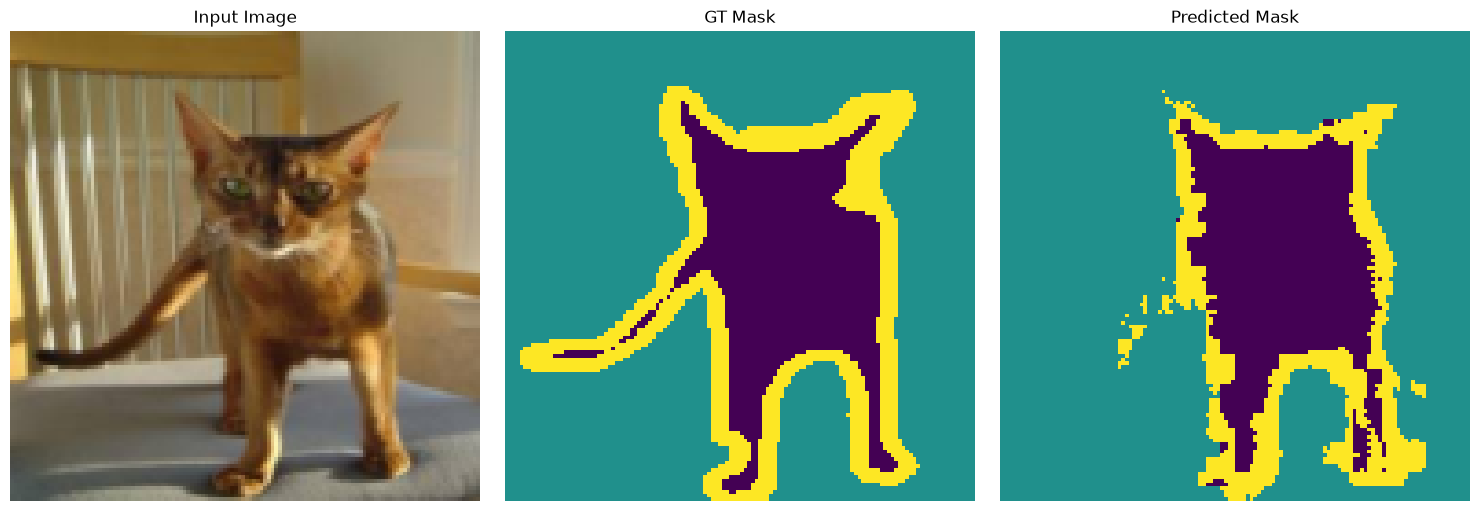

In [17]:
model.eval()

sample_image, sample_mask = test_dataset[2]   # (3, 128, 128), (128, 128)

with torch.no_grad():
    logits = model(sample_image.unsqueeze(0).to(DEVICE))   # (1, 3, 128, 128)
    pred_mask = logits.argmax(dim=1).squeeze(0).cpu()       # (128, 128)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(sample_image.permute(1, 2, 0).numpy())   # (C,H,W) -> (H,W,C)
axes[0].set_title('Input Image')
axes[0].axis('off')

axes[1].imshow(sample_mask.numpy())
axes[1].set_title('GT Mask')
axes[1].axis('off')

axes[2].imshow(pred_mask.numpy())
axes[2].set_title('Predicted Mask')
axes[2].axis('off')

plt.tight_layout()
plt.show()
